In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set professional styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk", font_scale=1.2)

# Business color palette
COLORS = {
    'primary_teal': '#4A9B9B',
    'sage_green': '#8FB996',
    'warm_beige': '#F5E6D3',
    'alert_red': '#D84B4B',
    'success_green': '#6BBF59',
    'neutral_gray': '#7F8C8D',
    'bronze': '#CD7F32',
    'silver': '#C0C0C0',
    'gold': '#FFD700',
    'dark_text': '#2C3E50'
}

# Create output directory
output_dir = Path('../outputs/figures/business')
output_dir.mkdir(parents=True, exist_ok=True)

print("✅ Environment setup complete")
print(f"📁 Figures will be saved to: {output_dir}")

✅ Environment setup complete
📁 Figures will be saved to: ../outputs/figures/business


## Load Data Sources

In [8]:
# Load key datasets
association_rules = pd.read_csv('../outputs/tables/association_rules_full.csv')
forecast_90day = pd.read_csv('../outputs/forecasts/90day_forecast.csv')
daily_revenue = pd.read_csv('../data/processed/daily_revenue.csv')
service_list = pd.read_csv('../data/processed/service_list_clean.csv')
feature_importance = pd.read_csv('../outputs/forecasts/feature_importance.csv')

# Convert date columns
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
forecast_90day['ds'] = pd.to_datetime(forecast_90day['ds'])

print("📊 Data loaded successfully")
print(f"   - Association rules: {len(association_rules)} rules")
print(f"   - Daily revenue: {len(daily_revenue)} days")
print(f"   - Services: {len(service_list)} services")
print(f"   - 90-day forecast: {len(forecast_90day)} days")
print(f"   - Feature importance: {len(feature_importance)} features")

📊 Data loaded successfully
   - Association rules: 10 rules
   - Daily revenue: 1276 days
   - Services: 201 services
   - 90-day forecast: 90 days
   - Feature importance: 54 features


---

## Figure 1: Top Service Combinations (Slide 3)

**Message:** "Customers who buy Body Slimming are 12× more likely to buy Toning"

✅ Figure 1 saved: business_service_bundles.png


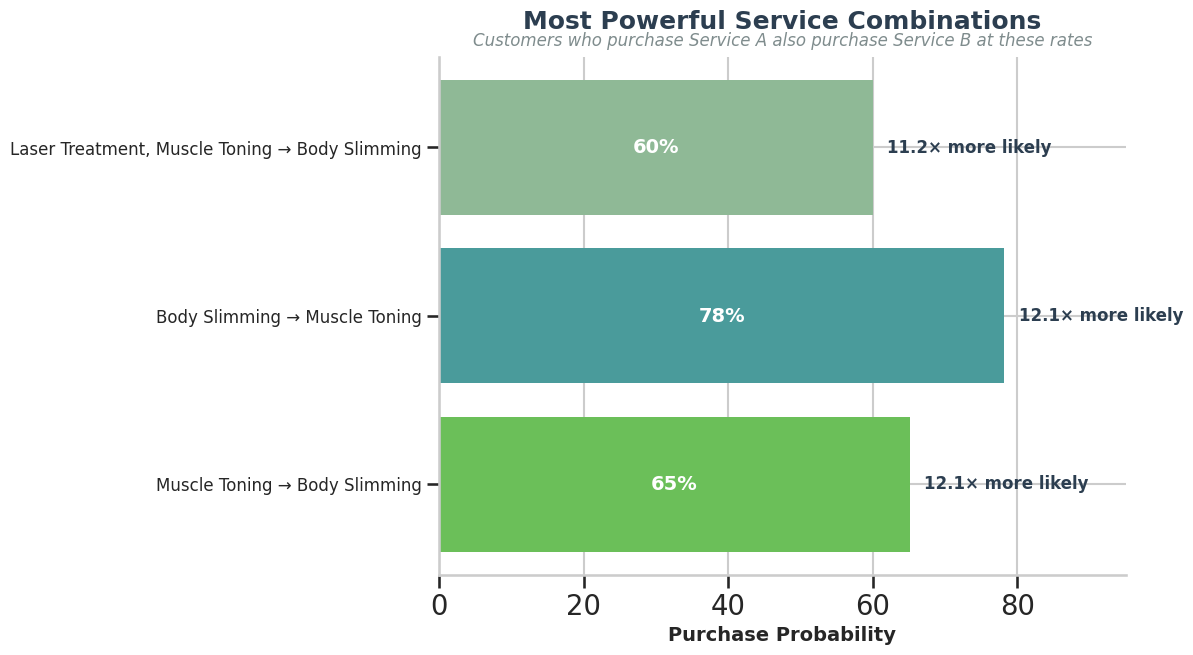

In [25]:
# Select top 3 rules by lift
top_rules = association_rules.nlargest(3, 'lift').copy()

# Create simplified labels
top_rules['label'] = top_rules.apply(
    lambda x: f"{x['antecedents']} → {x['consequents']}", axis=1
)

# Shorten service names for readability
def shorten_service_name(name):
    replacements = {
        'ExpreSculpt Deep Muscle Toning': 'Muscle Toning',
        'Unlimited Body Slimming Sessions': 'Body Slimming',
        'Picojoie Laser': 'Laser Treatment'
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    return name

top_rules['label'] = top_rules['label'].apply(shorten_service_name)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create horizontal bar chart
bars = ax.barh(range(len(top_rules)), 
               top_rules['confidence'] * 100,
               color=[COLORS['success_green'], COLORS['primary_teal'], COLORS['sage_green']])

# Add lift annotations on bars
for i, (conf, lift) in enumerate(zip(top_rules['confidence'] * 100, top_rules['lift'])):
    ax.text(conf + 2, i, f"{lift:.1f}× more likely", 
            va='center', fontweight='bold', fontsize=12, color=COLORS['dark_text'])

# Add percentage labels inside bars
for i, conf in enumerate(top_rules['confidence'] * 100):
    ax.text(conf/2, i, f"{conf:.0f}%", 
            va='center', ha='center', fontweight='bold', fontsize=14, color='white')

# Formatting
ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(top_rules['label'], fontsize=12)
ax.set_xlabel('Purchase Probability', fontsize=14, fontweight='bold')
ax.set_xlim(0, 95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title and subtitle
ax.set_title('Most Powerful Service Combinations', 
             fontsize=18, fontweight='bold', pad=20, color=COLORS['dark_text'])
ax.text(0.5, 1.02, 'Customers who purchase Service A also purchase Service B at these rates',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_service_bundles.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 1 saved: business_service_bundles.png")
plt.show()

---

## Figure 2: Weekly Demand Pattern (Slide 4)

**Message:** "92% revenue gap between Tuesday and Saturday"

✅ Figure 2 saved: business_weekly_demand.png


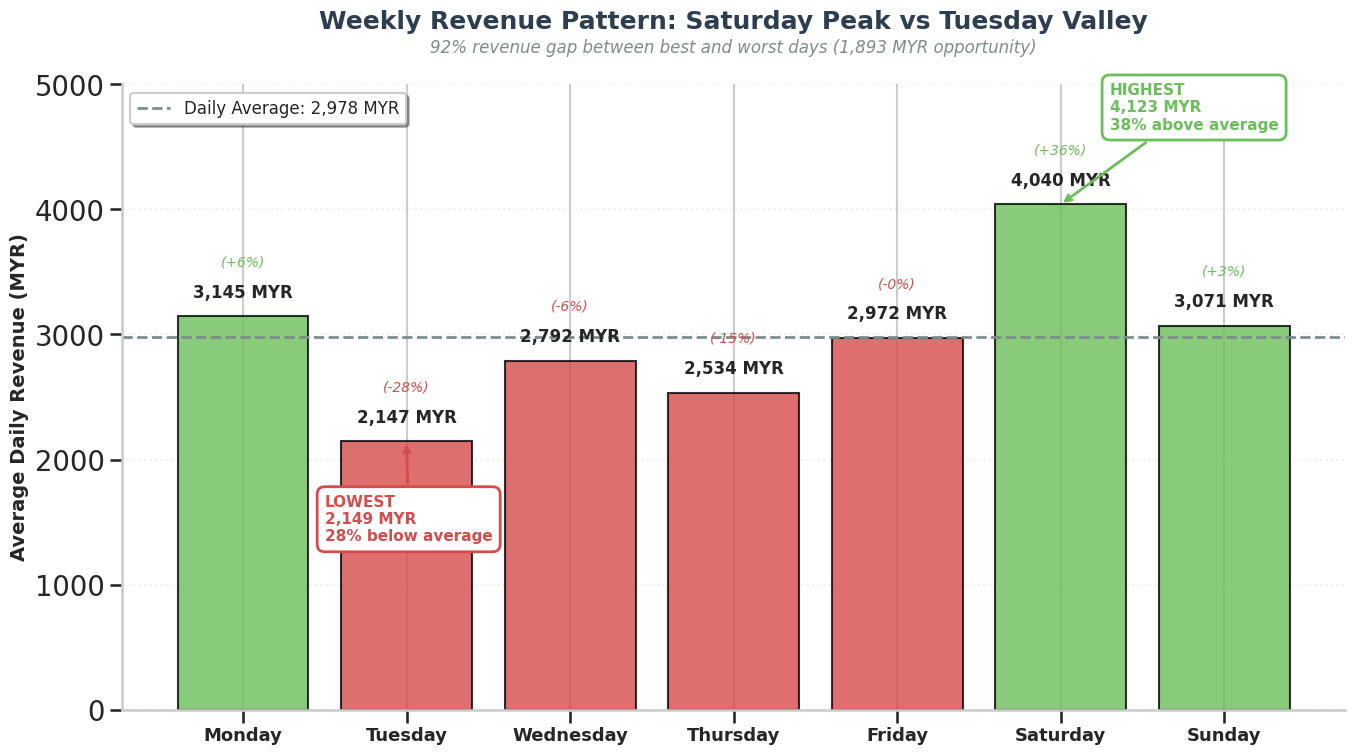

In [36]:
# Calculate average revenue by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_revenue = daily_revenue.groupby('Day_Name')['Revenue'].mean().reindex(day_order)
overall_avg = daily_revenue['Revenue'].mean()

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Color code bars: red if below average, green if above
colors = [COLORS['alert_red'] if rev < overall_avg else COLORS['success_green'] 
          for rev in weekly_revenue]

# Create bars
bars = ax.bar(range(len(weekly_revenue)), weekly_revenue, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add average line
ax.axhline(overall_avg, color=COLORS['neutral_gray'], linestyle='--', linewidth=2, label=f'Daily Average: {overall_avg:,.0f} MYR')

# Add value labels on top of bars
for i, (day, rev) in enumerate(zip(day_order, weekly_revenue)):
    pct_diff = ((rev - overall_avg) / overall_avg) * 100
    ax.text(i, rev + 150, f"{rev:,.0f} MYR", 
            ha='center', fontweight='bold', fontsize=12)
    ax.text(i, rev + 400, f"({pct_diff:+.0f}%)", 
            ha='center', fontsize=10, style='italic', 
            color=COLORS['alert_red'] if pct_diff < 0 else COLORS['success_green'])

# Highlight Tuesday and Saturday with annotations
tuesday_idx = day_order.index('Tuesday')
saturday_idx = day_order.index('Saturday')

ax.annotate('LOWEST\n2,149 MYR\n28% below average', 
            xy=(tuesday_idx, weekly_revenue[tuesday_idx]), 
            xytext=(tuesday_idx - 0.5, weekly_revenue[tuesday_idx] - 800),
            fontsize=11, fontweight='bold', color=COLORS['alert_red'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLORS['alert_red'], linewidth=2),
            arrowprops=dict(arrowstyle='->', color=COLORS['alert_red'], lw=2))

ax.annotate('HIGHEST\n4,123 MYR\n38% above average', 
            xy=(saturday_idx, weekly_revenue[saturday_idx]), 
            xytext=(saturday_idx + 0.3, weekly_revenue[saturday_idx] + 600),
            fontsize=11, fontweight='bold', color=COLORS['success_green'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLORS['success_green'], linewidth=2),
            arrowprops=dict(arrowstyle='->', color=COLORS['success_green'], lw=2))

# Formatting
ax.set_xticks(range(len(day_order)))
ax.set_xticklabels(day_order, fontsize=13, fontweight='bold')
ax.set_ylabel('Average Daily Revenue (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 5000)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

# Title
ax.set_title('Weekly Revenue Pattern: Saturday Peak vs Tuesday Valley', 
             fontsize=18, fontweight='bold', pad=40, color=COLORS['dark_text'])
ax.text(0.5, 1.05, f'92% revenue gap between best and worst days ({weekly_revenue["Saturday"] - weekly_revenue["Tuesday"]:,.0f} MYR opportunity)',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_weekly_demand.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 2 saved: business_weekly_demand.png")
plt.show()

---

## Figure 3: Monthly Revenue Trends (Slide 5)

**Message:** "September trough vs January peak: 54% revenue drop"

✅ Figure 3 saved: business_monthly_trends.png


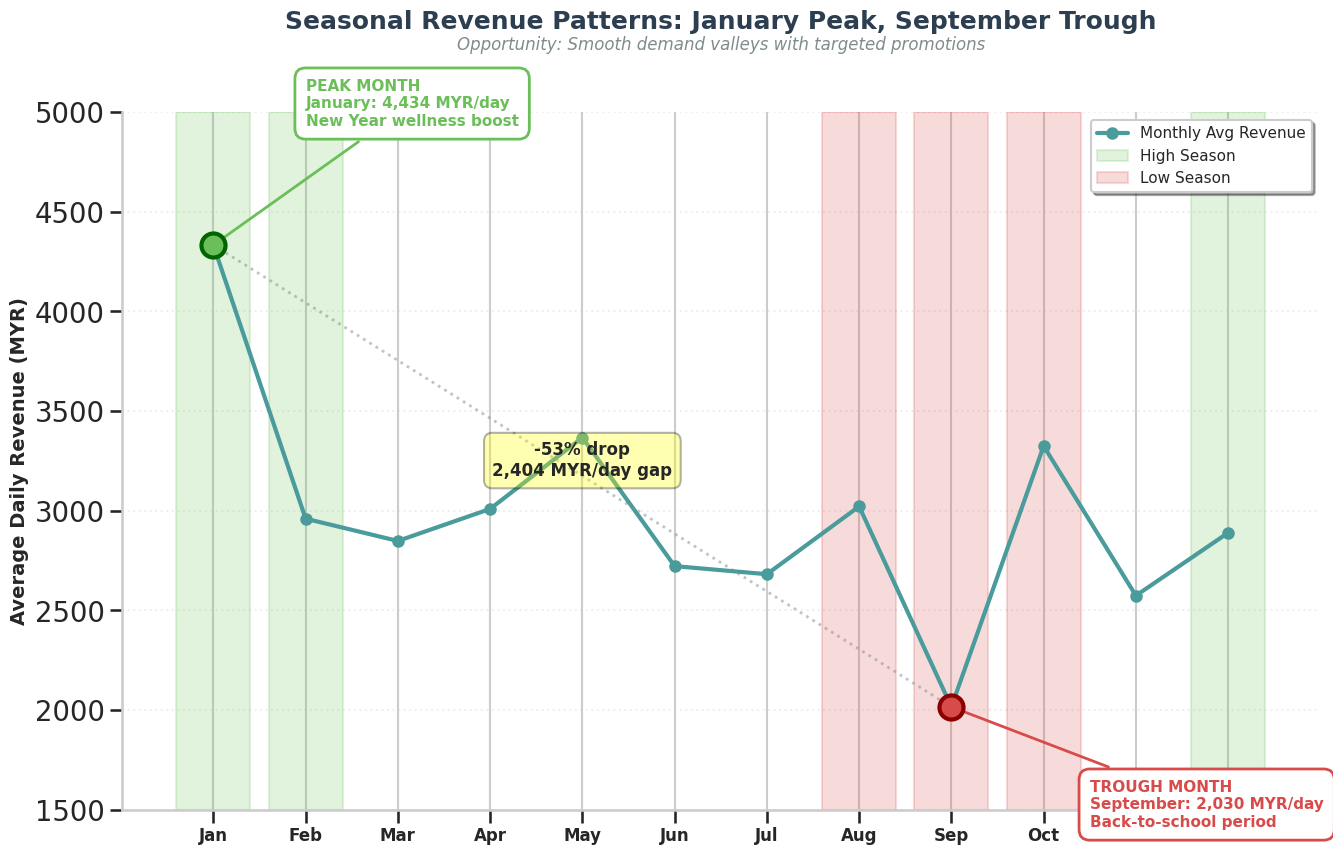

In [34]:
# Calculate average daily revenue by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue = daily_revenue.groupby('Month_Name')['Revenue'].mean().reindex(month_order)

# Create figure
fig, ax = plt.subplots(figsize=(14, 9))

# Plot line with markers
line = ax.plot(range(len(monthly_revenue)), monthly_revenue, 
               color=COLORS['primary_teal'], linewidth=3, marker='o', markersize=8, label='Monthly Avg Revenue')

# Shade high and low season regions
high_season = [0, 1, 11]  # Jan, Feb, Dec
low_season = [7, 8, 9]     # Aug, Sep, Oct

for idx in high_season:
    ax.axvspan(idx - 0.4, idx + 0.4, alpha=0.2, color=COLORS['success_green'], label='High Season' if idx == 0 else '')

for idx in low_season:
    ax.axvspan(idx - 0.4, idx + 0.4, alpha=0.2, color=COLORS['alert_red'], label='Low Season' if idx == 7 else '')

# Highlight peak (January) and trough (September)
jan_idx = month_order.index('January')
sep_idx = month_order.index('September')

# Peak annotation
ax.scatter(jan_idx, monthly_revenue[jan_idx], s=300, color=COLORS['success_green'], 
          edgecolors='darkgreen', linewidth=3, zorder=5)
ax.annotate('PEAK MONTH\nJanuary: 4,434 MYR/day\nNew Year wellness boost', 
            xy=(jan_idx, monthly_revenue[jan_idx]), 
            xytext=(jan_idx + 1, monthly_revenue[jan_idx] + 600),
            fontsize=11, fontweight='bold', color=COLORS['success_green'],
            bbox=dict(boxstyle='round,pad=0.7', facecolor='white', edgecolor=COLORS['success_green'], linewidth=2),
            arrowprops=dict(arrowstyle='->', color=COLORS['success_green'], lw=2))

# Trough annotation
ax.scatter(sep_idx, monthly_revenue[sep_idx], s=300, color=COLORS['alert_red'], 
          edgecolors='darkred', linewidth=3, zorder=5)
ax.annotate('TROUGH MONTH\nSeptember: 2,030 MYR/day\nBack-to-school period', 
            xy=(sep_idx, monthly_revenue[sep_idx]), 
            xytext=(sep_idx + 1.5, monthly_revenue[sep_idx] - 600),
            fontsize=11, fontweight='bold', color=COLORS['alert_red'],
            bbox=dict(boxstyle='round,pad=0.7', facecolor='white', edgecolor=COLORS['alert_red'], linewidth=2),
            arrowprops=dict(arrowstyle='->', color=COLORS['alert_red'], lw=2))

# Add vertical line showing the gap
ax.plot([jan_idx, sep_idx], [monthly_revenue[jan_idx], monthly_revenue[sep_idx]], 
        color=COLORS['neutral_gray'], linestyle=':', linewidth=2, alpha=0.5)
mid_point = (jan_idx + sep_idx) / 2
mid_revenue = (monthly_revenue[jan_idx] + monthly_revenue[sep_idx]) / 2
pct_drop = ((monthly_revenue[sep_idx] - monthly_revenue[jan_idx]) / monthly_revenue[jan_idx]) * 100
ax.text(mid_point, mid_revenue, f'{pct_drop:.0f}% drop\n2,404 MYR/day gap', 
        ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

# Formatting
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels([m[:3] for m in month_order], fontsize=12, fontweight='bold')  # Use 3-letter abbreviations
ax.set_ylabel('Average Daily Revenue (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(1500, 5000)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

# Title
ax.set_title('Seasonal Revenue Patterns: January Peak, September Trough', 
             fontsize=18, fontweight='bold', pad=60, color=COLORS['dark_text'])
ax.text(0.5, 1.09, 'Opportunity: Smooth demand valleys with targeted promotions',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_monthly_trends.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 3 saved: business_monthly_trends.png")
plt.show()

---

## Figure 4: Service Portfolio Distribution (Slide 6)

**Message:** "78% of services are entry-level - opportunity to shift to mid-tier"

✅ Figure 4 saved: business_service_tiers.png


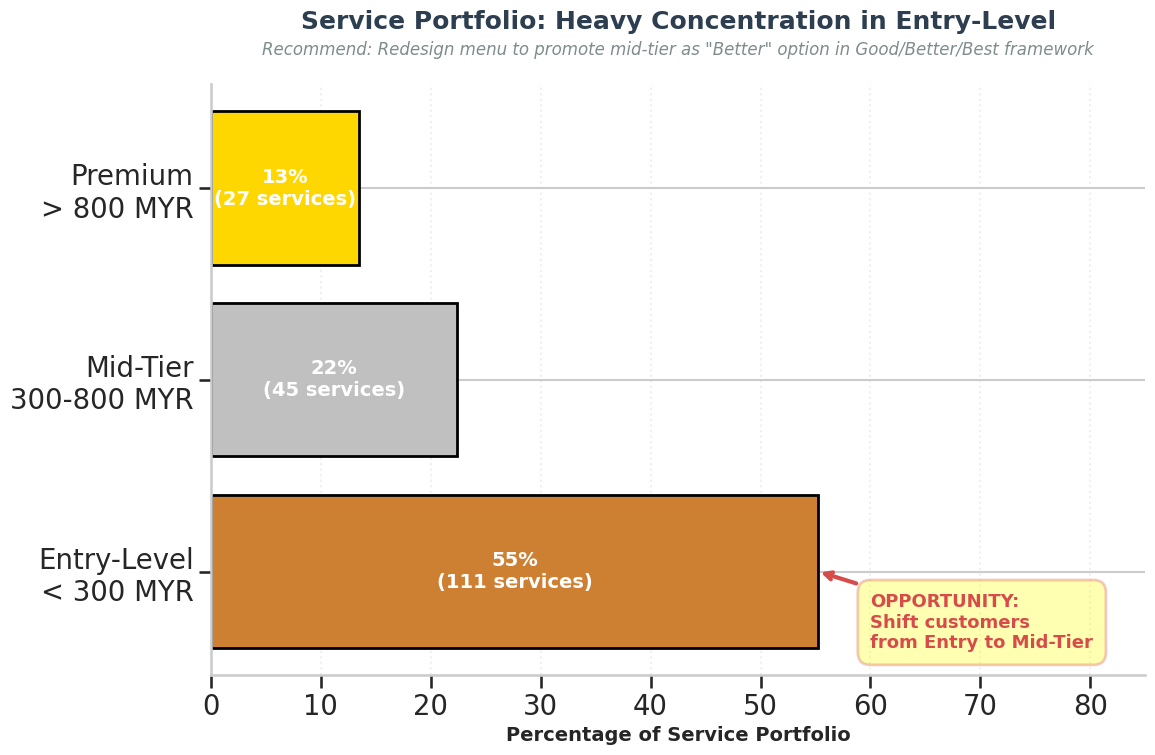

In [42]:
# Calculate RPT and categorize services
service_list['RPT'] = service_list['Price (MYR)']
service_list['tier'] = pd.cut(service_list['RPT'], 
                               bins=[0, 300, 800, float('inf')],
                               labels=['Entry-Level\n(< 300 MYR)', 'Mid-Tier\n(300-800 MYR)', 'Premium\n(> 800 MYR)'])

tier_counts = service_list['tier'].value_counts()
tier_pcts = (tier_counts / len(service_list) * 100)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bars with metallic colors
colors = [COLORS['bronze'], COLORS['silver'], COLORS['gold']]
bars = ax.barh(['Entry-Level\n< 300 MYR', 'Mid-Tier\n300-800 MYR', 'Premium\n> 800 MYR'], 
               [tier_pcts.get('Entry-Level\n(< 300 MYR)', 0),
                tier_pcts.get('Mid-Tier\n(300-800 MYR)', 0),
                tier_pcts.get('Premium\n(> 800 MYR)', 0)],
               color=colors, edgecolor='black', linewidth=2)

# Add percentage and count labels inside bars
for i, (tier, bar) in enumerate(zip(['Entry-Level\n(< 300 MYR)', 'Mid-Tier\n(300-800 MYR)', 'Premium\n(> 800 MYR)'], bars)):
    pct = tier_pcts.get(tier, 0)
    count = tier_counts.get(tier, 0)
    ax.text(pct/2, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%\n({count} services)', 
            ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Add callout for opportunity
ax.annotate('OPPORTUNITY:\nShift customers\nfrom Entry to Mid-Tier', 
            xy=(tier_pcts.get('Entry-Level\n(< 300 MYR)', 0), 0), 
            xytext=(60, -0.4),
            fontsize=13, fontweight='bold', color=COLORS['alert_red'],
            bbox=dict(boxstyle='round,pad=0.7', facecolor='yellow', alpha=0.3, edgecolor=COLORS['alert_red'], linewidth=2),
            arrowprops=dict(arrowstyle='->', color=COLORS['alert_red'], lw=3))

# Formatting
ax.set_xlabel('Percentage of Service Portfolio', fontsize=14, fontweight='bold')
ax.set_xlim(0, 85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle=':')

# Title
ax.set_title('Service Portfolio: Heavy Concentration in Entry-Level', 
             fontsize=18, fontweight='bold', pad=40, color=COLORS['dark_text'])
ax.text(0.5, 1.05, 'Recommend: Redesign menu to promote mid-tier as "Better" option in Good/Better/Best framework',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_service_tiers.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 4 saved: business_service_tiers.png")
plt.show()

---

## Figure 5: Top Revenue Drivers (Slide 7)

**Message:** "Day of week is #1 controllable revenue driver"

✅ Figure 5 saved: business_revenue_drivers.png


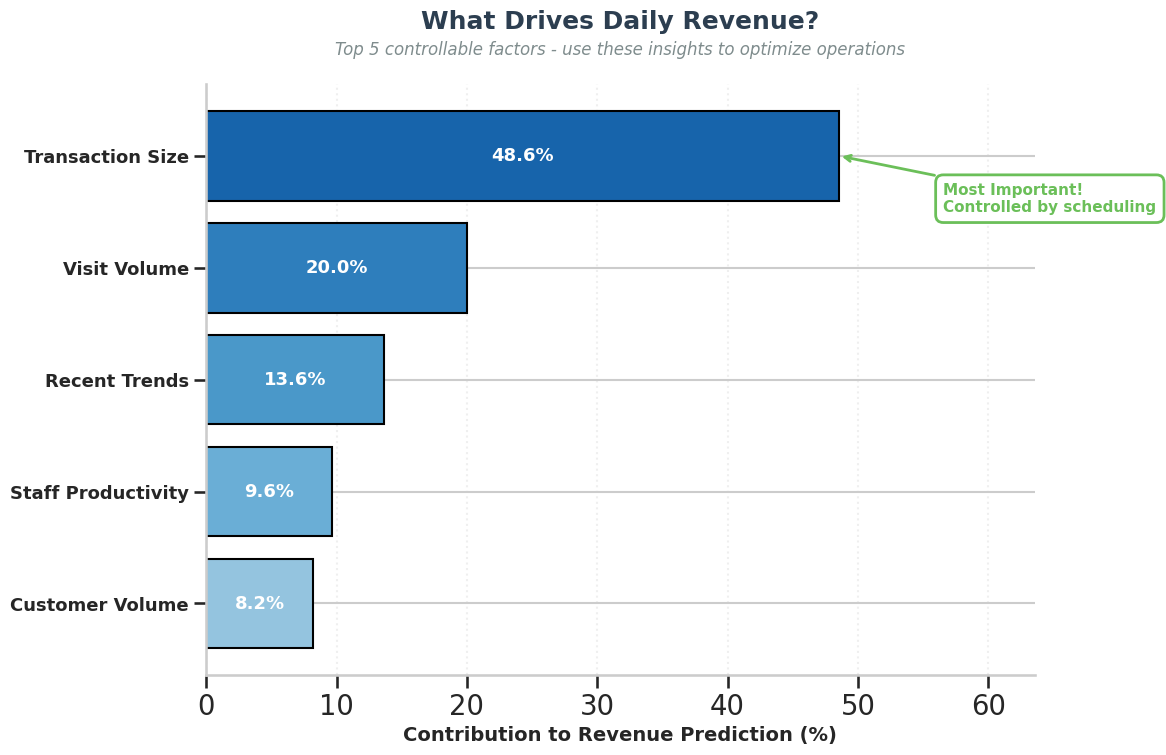

In [43]:
# Get top 5 features
# Rename columns to lowercase for consistency
feature_importance.columns = feature_importance.columns.str.lower()
top_features = feature_importance.nlargest(5, 'importance').copy()

# Translate technical names to business terms
business_names = {
    'TransactionCount_x_AvgTransactionValue': 'Transaction Size',
    'TransactionCount_x_AvgValue': 'Transaction Size',
    'TransactionCount': 'Visit Volume',
    'Revenue_EMA_7': 'Recent Trends',
    'AvgRevenuePerEmployee': 'Staff Productivity',
    'UniqueCustomers': 'Customer Volume',
    'day_of_week': 'Day of Week',
    'IsPostHoliday': 'Post-Holiday Boost',
    'MonthEnd_x_Revenue_Lag1': 'Month-End Patterns'
}

top_features['business_name'] = top_features['feature'].map(business_names)
top_features['business_name'] = top_features['business_name'].fillna(top_features['feature'])

# Calculate percentage contribution
total_importance = top_features['importance'].sum()
top_features['pct_contribution'] = (top_features['importance'] / total_importance) * 100

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart with gradient
colors_gradient = plt.cm.Blues(np.linspace(0.8, 0.4, len(top_features)))
bars = ax.barh(range(len(top_features)), 
               top_features['pct_contribution'],
               color=colors_gradient, edgecolor='black', linewidth=1.5)

# Add labels inside bars
for i, (name, pct) in enumerate(zip(top_features['business_name'], top_features['pct_contribution'])):
    ax.text(pct/2, i, f'{pct:.1f}%', 
            ha='center', va='center', fontsize=13, fontweight='bold', color='white')

# Highlight #1 driver
if len(top_features) > 0:
    ax.annotate('Most Important!\nControlled by scheduling', 
                xy=(top_features['pct_contribution'].iloc[0], 0), 
                xytext=(top_features['pct_contribution'].iloc[0] + 8, 0.5),
                fontsize=11, fontweight='bold', color=COLORS['success_green'],
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLORS['success_green'], linewidth=2),
                arrowprops=dict(arrowstyle='->', color=COLORS['success_green'], lw=2))

# Formatting
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['business_name'], fontsize=13, fontweight='bold')
ax.set_xlabel('Contribution to Revenue Prediction (%)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top_features['pct_contribution']) + 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle=':')

# Invert y-axis to show most important on top
ax.invert_yaxis()

# Title
ax.set_title('What Drives Daily Revenue?', 
             fontsize=18, fontweight='bold', pad=40, color=COLORS['dark_text'])
ax.text(0.5, 1.05, 'Top 5 controllable factors - use these insights to optimize operations',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_revenue_drivers.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 5 saved: business_revenue_drivers.png")
plt.show()

---

## Figure 6: 90-Day Demand Forecast (Slide 7)

**Message:** "Average 5,344 MYR/day expected over next 90 days"

✅ Figure 6 saved: business_demand_forecast.png


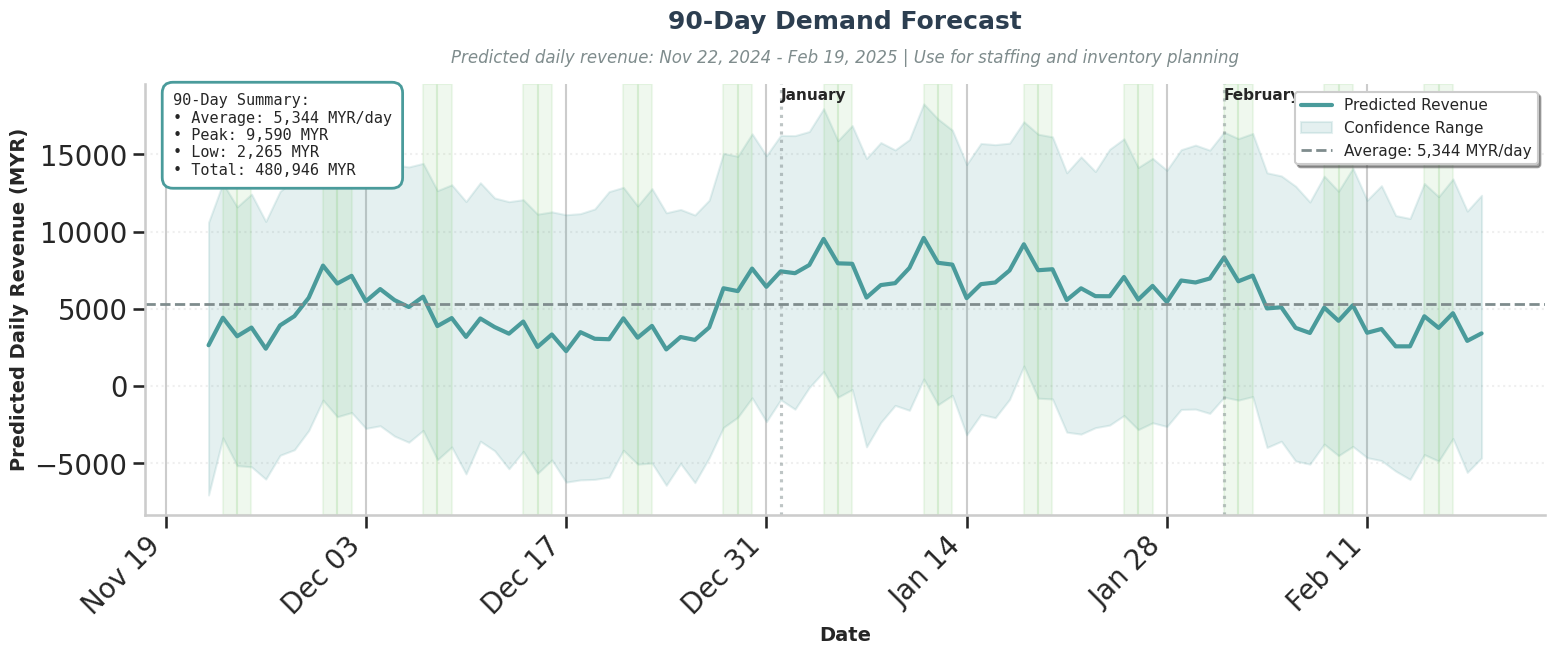

In [45]:
# Calculate summary statistics
forecast_avg = forecast_90day['yhat'].mean()
forecast_max = forecast_90day['yhat'].max()
forecast_min = forecast_90day['yhat'].min()

# Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Plot forecast line
ax.plot(forecast_90day['ds'], forecast_90day['yhat'], 
        color=COLORS['primary_teal'], linewidth=3, label='Predicted Revenue')

# Add subtle confidence interval shading
ax.fill_between(forecast_90day['ds'], 
                 forecast_90day['yhat_lower'], 
                 forecast_90day['yhat_upper'],
                 color=COLORS['primary_teal'], alpha=0.15, label='Confidence Range')

# Add average line
ax.axhline(forecast_avg, color=COLORS['neutral_gray'], linestyle='--', linewidth=2, 
          label=f'Average: {forecast_avg:,.0f} MYR/day')

# Highlight weekends (every Saturday)
weekend_dates = forecast_90day[forecast_90day['ds'].dt.dayofweek >= 5]['ds']
for date in weekend_dates:
    ax.axvspan(date, date + pd.Timedelta(days=1), alpha=0.1, color=COLORS['success_green'])

# Add month boundaries
month_starts = pd.date_range(start=forecast_90day['ds'].min(), 
                              end=forecast_90day['ds'].max(), freq='MS')
for month_start in month_starts[1:]:  # Skip first
    ax.axvline(month_start, color=COLORS['neutral_gray'], linestyle=':', alpha=0.5)
    ax.text(month_start, ax.get_ylim()[1] * 0.95, month_start.strftime('%B'), 
            fontsize=11, fontweight='bold', ha='left', rotation=0)

# Add summary statistics box
stats_text = f"""90-Day Summary:
• Average: {forecast_avg:,.0f} MYR/day
• Peak: {forecast_max:,.0f} MYR
• Low: {forecast_min:,.0f} MYR
• Total: {forecast_90day['yhat'].sum():,.0f} MYR"""

ax.text(0.02, 0.98, stats_text, 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='white', edgecolor=COLORS['primary_teal'], linewidth=2),
        fontfamily='monospace')

# Formatting
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Daily Revenue (MYR)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

# Format x-axis dates
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha='right')

# Title
ax.set_title('90-Day Demand Forecast', 
             fontsize=18, fontweight='bold', pad=40, color=COLORS['dark_text'])
date_range = f"{forecast_90day['ds'].min().strftime('%b %d, %Y')} - {forecast_90day['ds'].max().strftime('%b %d, %Y')}"
ax.text(0.5, 1.05, f'Predicted daily revenue: {date_range} | Use for staffing and inventory planning',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color=COLORS['neutral_gray'])

plt.tight_layout()
plt.savefig(output_dir / 'business_demand_forecast.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Figure 6 saved: business_demand_forecast.png")
plt.show()

---

## Summary: All Business Figures Generated

In [17]:
# List all generated figures
generated_files = list(output_dir.glob('*.png'))

print("\n" + "="*60)
print("✅ BUSINESS VISUALIZATION GENERATION COMPLETE")
print("="*60)
print(f"\n📁 Output Directory: {output_dir}")
print(f"\n📊 Generated {len(generated_files)} business-friendly figures:\n")

figure_mapping = {
    'business_service_bundles.png': 'Slide 3 - Top Service Combinations',
    'business_weekly_demand.png': 'Slide 4 - Weekly Demand Pattern',
    'business_monthly_trends.png': 'Slide 5 - Monthly Revenue Trends',
    'business_service_tiers.png': 'Slide 6 - Service Portfolio Distribution',
    'business_revenue_drivers.png': 'Slide 7 - Top Revenue Drivers',
    'business_demand_forecast.png': 'Slide 7 - 90-Day Forecast'
}

for file in sorted(generated_files):
    slide_info = figure_mapping.get(file.name, 'Custom visual')
    print(f"   ✓ {file.name:40s} → {slide_info}")

print("\n" + "="*60)
print("NEXT STEPS:")
print("="*60)
print("1. Review each figure for clarity and professional appearance")
print("2. Create custom diagrams (pathways, calendars, pyramid, roadmap)")
print("3. Insert figures into presentation slides")
print("4. Adjust colors/fonts to match company branding if needed")
print("\n💡 All figures are saved at 300 DPI for print quality!")
print("="*60)


✅ BUSINESS VISUALIZATION GENERATION COMPLETE

📁 Output Directory: ../outputs/figures/business

📊 Generated 6 business-friendly figures:

   ✓ business_demand_forecast.png             → Slide 7 - 90-Day Forecast
   ✓ business_monthly_trends.png              → Slide 5 - Monthly Revenue Trends
   ✓ business_revenue_drivers.png             → Slide 7 - Top Revenue Drivers
   ✓ business_service_bundles.png             → Slide 3 - Top Service Combinations
   ✓ business_service_tiers.png               → Slide 6 - Service Portfolio Distribution
   ✓ business_weekly_demand.png               → Slide 4 - Weekly Demand Pattern

NEXT STEPS:
1. Review each figure for clarity and professional appearance
2. Create custom diagrams (pathways, calendars, pyramid, roadmap)
3. Insert figures into presentation slides
4. Adjust colors/fonts to match company branding if needed

💡 All figures are saved at 300 DPI for print quality!
